In [463]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [ ]:
df_raw = pd.read_excel("/Users/macbook/Desktop/TAXI_PRICE_EXTENSION/DATA/INSURANCE/FINAL EXAMINATION/Data_For Midterm and Final Project.xlsx")
df = df_raw.copy()
selected_columns = [
    'PHUONG THUC CHO VAY', 'LOAIKH', 'SEX', 'CURRENCYCD', 'DESC_TIME',
    'MJACCTTYPDESC', 'ORGNAME', 'PARENTORGNAME', 'MUCDICHVAY',"OPEN_DATE","NGAYDENHAN",
    'BASE_BAL', 'CURR_BAL', 'DUNO_QD', 'LAISUAT',"NHOMNOMOI"
]

Filter dataframe

In [465]:
df = df[selected_columns]

Copy for processing

In [466]:
df["OPEN_DATE_clean"] = pd.NaT

For rows with numeric values ​​(serial date)

In [467]:
mask_numeric = df["OPEN_DATE"].apply(lambda x: str(x).replace('.', '').isnumeric())

The line is a valid date string.

In [ ]:
mask_string = ~mask_numeric

Apply conversions to each type

In [469]:
df.loc[mask_numeric, "OPEN_DATE_clean"] = pd.to_datetime(df.loc[mask_numeric, "OPEN_DATE"].astype(float),
                                                         origin="1899-12-30", unit="D", errors="coerce")

df.loc[mask_string, "OPEN_DATE_clean"] = pd.to_datetime(df.loc[mask_string, "OPEN_DATE"],
                                                        format="%d/%m/%Y", errors="coerce")

Check the results

In [470]:
print(df[["OPEN_DATE", "OPEN_DATE_clean"]].head())

    OPEN_DATE OPEN_DATE_clean
0  28/12/2010      2010-12-28
1       40490      2010-11-08
2  27/05/2010      2010-05-27
3       40276      2010-04-08
4  23/06/2010      2010-06-23


# 1. Check for lines with conversion errors (NaT)

In [471]:
invalid_dates = df[df["OPEN_DATE_clean"].isna()]

# 2. Count the number of errors

In [472]:
num_invalid = invalid_dates.shape[0]
print(f"🛑 Số lượng giá trị lỗi trong OPEN_DATE_clean: {num_invalid}")

🛑 Số lượng giá trị lỗi trong OPEN_DATE_clean: 0


# 3. Show some error examples (if any)

In [473]:
if num_invalid > 0:
    print("📋 Các giá trị gốc bị lỗi khi chuyển datetime:")
    display(invalid_dates[["OPEN_DATE"]].drop_duplicates().head(10))
else:
    print("✅ Không có lỗi nào trong OPEN_DATE_clean — tất cả đã chuyển đổi thành datetime thành công.")

✅ Không có lỗi nào trong OPEN_DATE_clean — tất cả đã chuyển đổi thành datetime thành công.


Make clean column default to NaT

In [474]:
df["NGAYDENHAN_clean"] = pd.NaT

Mask number: check if it is Excel serial number

In [475]:
mask_numeric_ngay = df["NGAYDENHAN"].apply(lambda x: str(x).replace('.', '').isnumeric())

The rest is a series of days (reverse mask)

In [476]:
mask_string_ngay = ~mask_numeric_ngay

Convert numeric values ​​(Excel serial)

In [477]:
df.loc[mask_numeric_ngay, "NGAYDENHAN_clean"] = pd.to_datetime(
    df.loc[mask_numeric_ngay, "NGAYDENHAN"].astype(float),
    origin="1899-12-30", unit="D", errors="coerce"
)

Convert string value

In [478]:
df.loc[mask_string_ngay, "NGAYDENHAN_clean"] = pd.to_datetime(
    df.loc[mask_string_ngay, "NGAYDENHAN"],
    format="%d/%m/%Y", errors="coerce"
)

Check for error values ​​(NaT)

In [479]:
invalid_ngay = df[df["NGAYDENHAN_clean"].isna()]

Count the number of errors

In [480]:
num_invalid_ngay = invalid_ngay.shape[0]
print(f"🛑 Số lượng lỗi trong NGAYDENHAN_clean: {num_invalid_ngay}")

🛑 Số lượng lỗi trong NGAYDENHAN_clean: 0


Show some example error values

In [481]:
if num_invalid_ngay > 0:
    print("📋 Các giá trị gốc bị lỗi khi chuyển datetime:")
    display(invalid_ngay[["NGAYDENHAN"]].drop_duplicates().head(10))
else:
    print("✅ Không có lỗi nào trong NGAYDENHAN_clean — tất cả đã chuyển đổi thành datetime thành công.")

df[["OPEN_DATE_clean", "NGAYDENHAN_clean"]].head()

✅ Không có lỗi nào trong NGAYDENHAN_clean — tất cả đã chuyển đổi thành datetime thành công.


,OPEN_DATE_clean,NGAYDENHAN_clean
0,2010-12-28,2020-03-12
1,2010-11-08,2030-07-28
2,2010-05-27,2030-05-26
3,2010-04-08,2013-04-08
4,2010-06-23,2030-06-23


Check min and max of OPEN_DATE_clean

In [482]:
open_min = df["OPEN_DATE_clean"].min()
open_max = df["OPEN_DATE_clean"].max()

Check min and max of NgayDENHAN_clean

In [483]:
due_min = df["NGAYDENHAN_clean"].min()
due_max = df["NGAYDENHAN_clean"].max()

Print results

In [484]:
print("📅 Thông tin thời gian:")
print(f"🗓️ OPEN_DATE_clean: từ {open_min.date()} đến {open_max.date()}")
print(f"📅 NGAYDENHAN_clean: từ {due_min.date()} đến {due_max.date()}")

📅 Thông tin thời gian:
🗓️ OPEN_DATE_clean: từ 2004-02-04 đến 2020-12-08
📅 NGAYDENHAN_clean: từ 2006-11-27 đến 2121-04-30


In [485]:
# Bước 1: Xác định giá trị cần sửa
wrong_date = pd.to_datetime("2121-04-30")
correct_date = pd.to_datetime("2021-04-30")

# Bước 2: Cập nhật lại
df.loc[df["NGAYDENHAN_clean"] == wrong_date, "NGAYDENHAN_clean"] = correct_date

# Bước 3: Kiểm tra lại
print("✅ Đã cập nhật xong. Kiểm tra các giá trị có thể từng sai:")
print(df[df["NGAYDENHAN_clean"] == correct_date][["NGAYDENHAN", "NGAYDENHAN_clean"]].head())

✅ Đã cập nhật xong. Kiểm tra các giá trị có thể từng sai:
       NGAYDENHAN NGAYDENHAN_clean
61352  30/04/2021       2021-04-30
63687  30/04/2021       2021-04-30
66008  30/04/2021       2021-04-30
68990  30/04/2021       2021-04-30
70131  30/04/2021       2021-04-30


# DATA VISUALIZATION

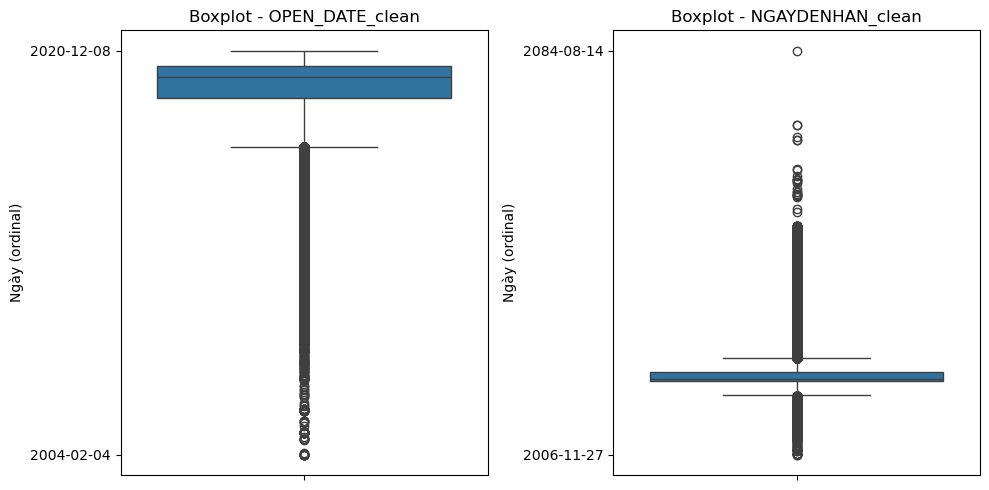

In [486]:
import matplotlib.pyplot as plt
import seaborn as sns

# Chuyển datetime về dạng số (timestamp)
df["OPEN_DATE_NUM"] = df["OPEN_DATE_clean"].map(pd.Timestamp.toordinal)
df["NGAYDENHAN_NUM"] = df["NGAYDENHAN_clean"].map(pd.Timestamp.toordinal)

# Vẽ boxplot
plt.figure(figsize=(10, 5))

# OPEN_DATE
plt.subplot(1, 2, 1)
sns.boxplot(y=df["OPEN_DATE_NUM"])
plt.title("Boxplot - OPEN_DATE_clean")
plt.ylabel("Ngày (ordinal)")
plt.yticks(
    ticks=[int(df["OPEN_DATE_NUM"].min()), int(df["OPEN_DATE_NUM"].max())],
    labels=[df["OPEN_DATE_clean"].min().date(), df["OPEN_DATE_clean"].max().date()]
)

# NGAYDENHAN
plt.subplot(1, 2, 2)
sns.boxplot(y=df["NGAYDENHAN_NUM"])
plt.title("Boxplot - NGAYDENHAN_clean")
plt.ylabel("Ngày (ordinal)")
plt.yticks(
    ticks=[int(df["NGAYDENHAN_NUM"].min()), int(df["NGAYDENHAN_NUM"].max())],
    labels=[df["NGAYDENHAN_clean"].min().date(), df["NGAYDENHAN_clean"].max().date()]
)

plt.tight_layout()
plt.show()

Extract time component

In [487]:
df["OPEN_YEAR"] = df["OPEN_DATE_clean"].dt.year
df["OPEN_MONTH"] = df["OPEN_DATE_clean"].dt.month
df["OPEN_DAYOFWEEK"] = df["OPEN_DATE_clean"].dt.dayofweek  # 0 = Monday

Extract year, month, day of the week from the NgayDenhan_clean column

In [488]:
df["DUE_YEAR"] = df["NGAYDENHAN_clean"].dt.year
df["DUE_MONTH"] = df["NGAYDENHAN_clean"].dt.month
df["DUE_DAYOFWEEK"] = df["NGAYDENHAN_clean"].dt.dayofweek  # 0 = Monday, 6 = Sunday

df.head()

,PHUONG THUC CHO VAY,LOAIKH,SEX,CURRENCYCD,DESC_TIME,MJACCTTYPDESC,ORGNAME,PARENTORGNAME,MUCDICHVAY,OPEN_DATE,NGAYDENHAN,BASE_BAL,CURR_BAL,DUNO_QD,LAISUAT,NHOMNOMOI,OPEN_DATE_clean,NGAYDENHAN_clean,OPEN_DATE_NUM,NGAYDENHAN_NUM,OPEN_YEAR,OPEN_MONTH,OPEN_DAYOFWEEK,DUE_YEAR,DUE_MONTH,DUE_DAYOFWEEK
0,CV TG NGAY VND,1,ONG,VND,Vay ngan han,Vay Tieu dung,KLB - CN KHANH HOA,KLB - CN KHANH HOA,1900-SX-DV Tu t.dung Gia dinh,28/12/2010,43902,787127020.0,851714900.0,851714900.0,0.12,1,2010-12-28,2020-03-12,734134,737496,2010,12,1,2020,3,3
1,CV TG NGAY VND,1,ONG,VND,Vay ngan han,Vay Tieu dung,KLB - PGD CAI LANG,KLB - CN DA NANG,1811-CV mua Xe may tra gop,40490,28/07/2030,333388030.0,142450650.0,142450650.0,0.18,1,2010-11-08,2030-07-28,734084,741286,2010,11,0,2030,7,6
2,CV TG NGAY VND,1,MR,VND,Vay ngan han,Vay Tieu dung,KLB - CN DA NANG,KLB - CN DA NANG,1870-CV TG Sinh hoat Tieu dung,27/05/2010,26/05/2030,311014800.0,357000690.0,357000690.0,0.18,1,2010-05-27,2030-05-26,733919,741223,2010,5,3,2030,5,6
3,CV TL TH LAI DINH KY VND,1,NaN,VND,Vay trung han,Vay Tieu dung,KLB - PGD DIEN KHANH,KLB - CN KHANH HOA,1830-CV Sua chua Nha de o,40276,41372,35600000.0,35600000.0,35600000.0,0.24,5,2010-04-08,2013-04-08,733870,734966,2010,4,3,2013,4,0
4,CV TG NGAY VND,1,MR,VND,Vay ngan han,Vay Tieu dung,KLB - CN DA NANG,KLB - CN DA NANG,1870-CV TG Sinh hoat Tieu dung,23/06/2010,23/06/2030,430174020.0,88246180.0,88246180.0,0.18,1,2010-06-23,2030-06-23,733946,741251,2010,6,2,2030,6,6


In [489]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

In [490]:
# 2. Chuẩn hóa giới tính
sex_mapping = {
    'ONG': 'MR', 'MR': 'MR',
    'BA': 'MRS', 'MRS': 'MRS', 'MS': 'MRS'
}
df['SEX'] = df['SEX'].map(sex_mapping).fillna('UNKNOWN')

In [491]:
# 3. Tạo biến target
df['target'] = df['NHOMNOMOI'].apply(lambda x: 1 if x == 1 else 0)

In [492]:
# 4. Tạo các biến thời gian từ ngày mở và ngày đến hạn
df["OPEN_YEAR"] = df["OPEN_DATE_clean"].dt.year
df["OPEN_MONTH"] = df["OPEN_DATE_clean"].dt.month
df["OPEN_DAYOFWEEK"] = df["OPEN_DATE_clean"].dt.dayofweek

df["DUE_YEAR"] = df["NGAYDENHAN_clean"].dt.year
df["DUE_MONTH"] = df["NGAYDENHAN_clean"].dt.month
df["DUE_DAYOFWEEK"] = df["NGAYDENHAN_clean"].dt.dayofweek

In [493]:
# 5. Bỏ các cột không cần
df_model = df.drop(columns=[
    'NHOMNOMOI',
    'OPEN_DATE', 'NGAYDENHAN',             # nếu có trong df
    'OPEN_DATE_clean', 'NGAYDENHAN_clean',  # đã sinh ra các biến thời gian rồi
    'OPEN_DATE_NUM',	'NGAYDENHAN_NUM'
])

In [494]:
# 6. Xác định các biến
numeric_cols = ['BASE_BAL', 'CURR_BAL', 'DUNO_QD', 'LAISUAT', 'OPEN_YEAR', 'DUE_YEAR']
categorical_cols = [col for col in df_model.columns if col not in numeric_cols + ['target']]

In [495]:
# 7. Chia dữ liệu thành train/test
X = df_model.drop(columns=['target'])
y = df_model['target']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [496]:
# 8. Ép kiểu categorical về string cho cả train và test
for col in categorical_cols:
    X_train[col] = X_train[col].astype(str)
    X_test[col] = X_test[col].astype(str)

In [497]:
# 9. ColumnTransformer: chuẩn hóa và one-hot encode
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ]
)

In [498]:
# 10. Fit và transform dữ liệu
X_train_enc = preprocessor.fit_transform(X_train)
X_test_enc = preprocessor.transform(X_test)

In [499]:
# 11. In kết quả
print("Categorical columns:", categorical_cols)
print("Numeric columns:", numeric_cols)
print("Kích thước tập train sau biến đổi:", X_train_enc.shape)
print("Kích thước tập test sau biến đổi:", X_test_enc.shape)

df_model.head()

Categorical columns: ['PHUONG THUC CHO VAY', 'LOAIKH', 'SEX', 'CURRENCYCD', 'DESC_TIME', 'MJACCTTYPDESC', 'ORGNAME', 'PARENTORGNAME', 'MUCDICHVAY', 'OPEN_MONTH', 'OPEN_DAYOFWEEK', 'DUE_MONTH', 'DUE_DAYOFWEEK']
Numeric columns: ['BASE_BAL', 'CURR_BAL', 'DUNO_QD', 'LAISUAT', 'OPEN_YEAR', 'DUE_YEAR']
Kích thước tập train sau biến đổi: (72275, 352)
Kích thước tập test sau biến đổi: (18069, 352)


,PHUONG THUC CHO VAY,LOAIKH,SEX,CURRENCYCD,DESC_TIME,MJACCTTYPDESC,ORGNAME,PARENTORGNAME,MUCDICHVAY,BASE_BAL,CURR_BAL,DUNO_QD,LAISUAT,OPEN_YEAR,OPEN_MONTH,OPEN_DAYOFWEEK,DUE_YEAR,DUE_MONTH,DUE_DAYOFWEEK,target
0,CV TG NGAY VND,1,MR,VND,Vay ngan han,Vay Tieu dung,KLB - CN KHANH HOA,KLB - CN KHANH HOA,1900-SX-DV Tu t.dung Gia dinh,787127020.0,851714900.0,851714900.0,0.12,2010,12,1,2020,3,3,1
1,CV TG NGAY VND,1,MR,VND,Vay ngan han,Vay Tieu dung,KLB - PGD CAI LANG,KLB - CN DA NANG,1811-CV mua Xe may tra gop,333388030.0,142450650.0,142450650.0,0.18,2010,11,0,2030,7,6,1
2,CV TG NGAY VND,1,MR,VND,Vay ngan han,Vay Tieu dung,KLB - CN DA NANG,KLB - CN DA NANG,1870-CV TG Sinh hoat Tieu dung,311014800.0,357000690.0,357000690.0,0.18,2010,5,3,2030,5,6,1
3,CV TL TH LAI DINH KY VND,1,UNKNOWN,VND,Vay trung han,Vay Tieu dung,KLB - PGD DIEN KHANH,KLB - CN KHANH HOA,1830-CV Sua chua Nha de o,35600000.0,35600000.0,35600000.0,0.24,2010,4,3,2013,4,0,0
4,CV TG NGAY VND,1,MR,VND,Vay ngan han,Vay Tieu dung,KLB - CN DA NANG,KLB - CN DA NANG,1870-CV TG Sinh hoat Tieu dung,430174020.0,88246180.0,88246180.0,0.18,2010,6,2,2030,6,6,1


In [500]:
# Hiển thị tối đa tất cả cột
pd.set_option('display.max_columns', None)

# (Tùy chọn) Hiển thị tối đa nhiều dòng hơn nếu bạn cần
pd.set_option('display.max_rows', 100)

# (Tùy chọn) Mở rộng chiều rộng màn hình hiển thị
pd.set_option('display.width', None)

# (Tùy chọn) Không cắt nội dung trong mỗi ô
pd.set_option('display.max_colwidth', None)
df_model.head()

,PHUONG THUC CHO VAY,LOAIKH,SEX,CURRENCYCD,DESC_TIME,MJACCTTYPDESC,ORGNAME,PARENTORGNAME,MUCDICHVAY,BASE_BAL,CURR_BAL,DUNO_QD,LAISUAT,OPEN_YEAR,OPEN_MONTH,OPEN_DAYOFWEEK,DUE_YEAR,DUE_MONTH,DUE_DAYOFWEEK,target
0,CV TG NGAY VND,1,MR,VND,Vay ngan han,Vay Tieu dung,KLB - CN KHANH HOA,KLB - CN KHANH HOA,1900-SX-DV Tu t.dung Gia dinh,787127020.0,851714900.0,851714900.0,0.12,2010,12,1,2020,3,3,1
1,CV TG NGAY VND,1,MR,VND,Vay ngan han,Vay Tieu dung,KLB - PGD CAI LANG,KLB - CN DA NANG,1811-CV mua Xe may tra gop,333388030.0,142450650.0,142450650.0,0.18,2010,11,0,2030,7,6,1
2,CV TG NGAY VND,1,MR,VND,Vay ngan han,Vay Tieu dung,KLB - CN DA NANG,KLB - CN DA NANG,1870-CV TG Sinh hoat Tieu dung,311014800.0,357000690.0,357000690.0,0.18,2010,5,3,2030,5,6,1
3,CV TL TH LAI DINH KY VND,1,UNKNOWN,VND,Vay trung han,Vay Tieu dung,KLB - PGD DIEN KHANH,KLB - CN KHANH HOA,1830-CV Sua chua Nha de o,35600000.0,35600000.0,35600000.0,0.24,2010,4,3,2013,4,0,0
4,CV TG NGAY VND,1,MR,VND,Vay ngan han,Vay Tieu dung,KLB - CN DA NANG,KLB - CN DA NANG,1870-CV TG Sinh hoat Tieu dung,430174020.0,88246180.0,88246180.0,0.18,2010,6,2,2030,6,6,1


🔍 Phân bố lớp target:
target
1    80280
0    10064
Name: count, dtype: int64

📊 Tỷ lệ phần trăm mỗi lớp:
target
1    88.86
0    11.14
Name: proportion, dtype: float64


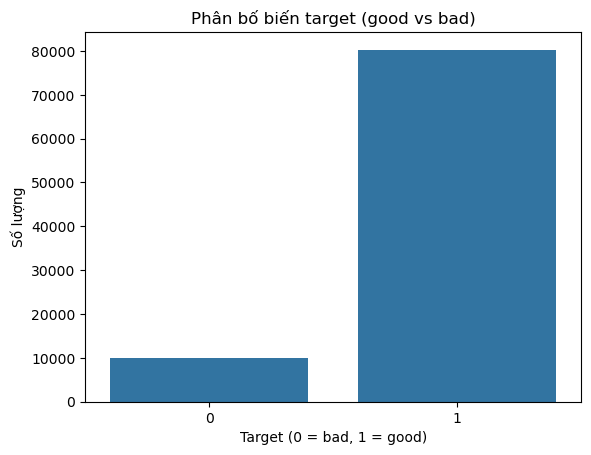

In [501]:
#Xem tỷ lệ unbalance của biến target
print("🔍 Phân bố lớp target:")
print(df["target"].value_counts())
print("\n📊 Tỷ lệ phần trăm mỗi lớp:")
print(df["target"].value_counts(normalize=True).round(4) * 100)
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(data=df, x="target")
plt.title("Phân bố biến target (good vs bad)")
plt.xlabel("Target (0 = bad, 1 = good)")
plt.ylabel("Số lượng")
plt.show()

"""✅ Step 1: Copy df_model for separate processing"""

In [502]:
df_work = df_model.copy()

"""✅ Step 2: Redefine the variables

In [503]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

Numerical and categorical lists

In [504]:
numeric_cols = ['BASE_BAL', 'CURR_BAL', 'DUNO_QD', 'LAISUAT', 'OPEN_YEAR', 'DUE_YEAR']
categorical_cols = [col for col in df_work.columns if col not in numeric_cols + ['target']]


X/y separation

In [505]:
X = df_work.drop(columns=["target"])
y = df_work["target"]

Split train/test

In [506]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

Categorical casting

In [507]:
for col in categorical_cols:
    X_train[col] = X_train[col].astype(str)
    X_test[col] = X_test[col].astype(str)

#✅ Step 3: Encode with ColumnTransformer

In [508]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ]
)

Fit + transform

In [509]:
X_train_enc = preprocessor.fit_transform(X_train)
X_test_enc = preprocessor.transform(X_test)

from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_enc, y_train)

#4 ✅ Step 4: Apply SMOTE and save to new variable

Print confirmation

In [510]:
from collections import Counter
print("✅ SMOTE applied. Class distribution:")
print(Counter(y_train_smote))

✅ SMOTE applied. Class distribution:
Counter({1: 64224, 0: 64224})


# Logistic model

In [511]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import pandas as pd

1. Initialize and train the Logistic Regression model

In [512]:
log_model = LogisticRegression(class_weight="balanced",max_iter=1000, random_state=42)
log_model.fit(X_train_smote, y_train_smote)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

2. Prediction on test set

In [513]:
y_pred_log = log_model.predict(X_test_enc)
y_proba_log = log_model.predict_proba(X_test_enc)[:, 1]  # Xác suất cho class "good"

3. Print classification report

In [514]:
print("🔍 Classification Report:")
print(classification_report(y_test, y_pred_log, target_names=["bad", "good"]))

🔍 Classification Report:
              precision    recall  f1-score   support

         bad       0.39      0.74      0.51      2013
        good       0.96      0.86      0.91     16056

    accuracy                           0.84     18069
   macro avg       0.68      0.80      0.71     18069
weighted avg       0.90      0.84      0.86     18069



4. In confusion matrix

In [515]:
print("\n📊 Confusion Matrix:")
print(pd.DataFrame(
    confusion_matrix(y_test, y_pred_log),
    index=["Actual: bad", "Actual: good"],
    columns=["Predicted: bad", "Predicted: good"]
))


📊 Confusion Matrix:
              Predicted: bad  Predicted: good
Actual: bad             1481              532
Actual: good            2280            13776


5. Calculate AUC

In [516]:
auc_score = roc_auc_score(y_test, y_proba_log)
print(f"\n🎯 ROC AUC Score: {auc_score:.4f}")


🎯 ROC AUC Score: 0.8764


6. Draw Confusion Matrix using heatmap

/var/folders/2w/0ds979vs33z3m70t85hh_cp00000gn/T/ipykernel_70096/3199016841.py:13: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


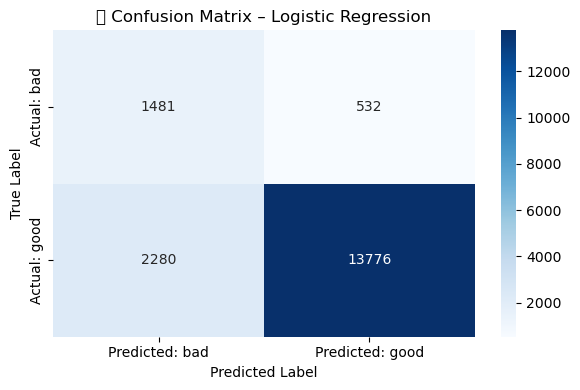

In [517]:
import seaborn as sns
import matplotlib.pyplot as plt

conf_matrix = confusion_matrix(y_test, y_pred_log)

plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Predicted: bad", "Predicted: good"],
            yticklabels=["Actual: bad", "Actual: good"])
plt.title("🔍 Confusion Matrix – Logistic Regression")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

In [518]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

Declare the parameters to be searched

In [519]:
param_grid = {
    'C': [0.1, 1],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']
}


Find the optimal Logistic Regression model according to F1-score

In [520]:
grid = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    param_grid,
    cv=3,
    scoring='f1',
    n_jobs=-1  # sử dụng toàn bộ CPU để tăng tốc
)

Fit model on SMOTE passed data

In [521]:
grid.fit(X_train_smote, y_train_smote)

GridSearchCV(cv=3, estimator=LogisticRegression(max_iter=1000, random_state=42),
             n_jobs=-1,
             param_grid={'C': [0.1, 1], 'penalty': ['l1', 'l2'],
                         'solver': ['liblinear']},
             scoring='f1')

In [522]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score, roc_auc_score
import pandas as pd

In [523]:
# 1. In tham số tốt nhất và F1 trên cross-validation
print("✅ Best Parameters:", grid.best_params_)
print(f"✅ Best Cross-Validated F1 Score: {grid.best_score_:.4f}")

# 2. Lấy mô hình tốt nhất
best_model = grid.best_estimator_

# 3. Dự đoán trên tập test
y_pred_best = best_model.predict(X_test_enc)
y_proba_best = best_model.predict_proba(X_test_enc)[:, 1]

# 4. Đánh giá mô hình
print("\n📊 Classification Report (Test Set):")
print(classification_report(y_test, y_pred_best, target_names=["bad", "good"]))

print("📉 Confusion Matrix:")
print(pd.DataFrame(
    confusion_matrix(y_test, y_pred_best),
    index=["Actual: bad", "Actual: good"],
    columns=["Predicted: bad", "Predicted: good"]
))

# 5. F1 và AUC
f1 = f1_score(y_test, y_pred_best)
auc = roc_auc_score(y_test, y_proba_best)
print(f"\n🎯 Test F1 Score: {f1:.4f}")
print(f"🎯 Test ROC AUC Score: {auc:.4f}")

✅ Best Parameters: {'C': 1, 'penalty': 'l1', 'solver': 'liblinear'}
✅ Best Cross-Validated F1 Score: 0.8307

📊 Classification Report (Test Set):
              precision    recall  f1-score   support

         bad       0.40      0.73      0.52      2013
        good       0.96      0.86      0.91     16056

    accuracy                           0.85     18069
   macro avg       0.68      0.80      0.71     18069
weighted avg       0.90      0.85      0.87     18069

📉 Confusion Matrix:
              Predicted: bad  Predicted: good
Actual: bad             1477              536
Actual: good            2233            13823

🎯 Test F1 Score: 0.9090
🎯 Test ROC AUC Score: 0.8771


In [524]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import pandas as pd

In [525]:
# Khởi tạo và huấn luyện mô hình
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_smote, y_train_smote)

# Dự đoán xác suất
y_proba_rf = rf_model.predict_proba(X_test_enc)[:, 1]

# === Select custom threshold ===

Try values ​​like 0.3, 0.4, 0.45 to increase recall for bad

In [526]:
threshold = 0.7  
y_pred_rf_thresh = (y_proba_rf >= threshold).astype(int)

Evaluate the model at the new threshold

In [527]:
print(f"\n📊 Classification Report tại threshold = {threshold}:")
print(classification_report(y_test, y_pred_rf_thresh, target_names=["bad", "good"]))

print("\n📉 Confusion Matrix:")
print(pd.DataFrame(confusion_matrix(y_test, y_pred_rf_thresh),
                   index=["Actual: bad", "Actual: good"],
                   columns=["Predicted: bad", "Predicted: good"]))

print(f"🎯 ROC AUC Score: {roc_auc_score(y_test, y_proba_rf):.4f}")


📊 Classification Report tại threshold = 0.7:
              precision    recall  f1-score   support

         bad       0.62      0.69      0.65      2013
        good       0.96      0.95      0.95     16056

    accuracy                           0.92     18069
   macro avg       0.79      0.82      0.80     18069
weighted avg       0.92      0.92      0.92     18069


📉 Confusion Matrix:
              Predicted: bad  Predicted: good
Actual: bad             1393              620
Actual: good             863            15193
🎯 ROC AUC Score: 0.9052


In [528]:
import matplotlib.pyplot as plt
import seaborn as sns

Calculate confusion matrix

In [529]:
cm = confusion_matrix(y_test, y_pred_rf_thresh)
labels = ["Bad", "Good"]

Draw heatmap for confusion matrix

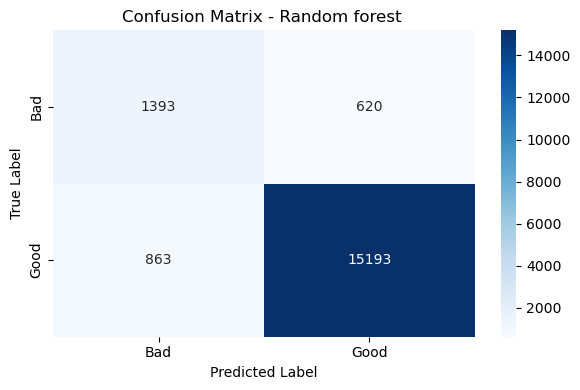

In [530]:
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title(f"Confusion Matrix - Random forest ")
plt.tight_layout()
plt.show()

Optimize threshold classification

In [531]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

# Xác suất dự đoán class 1 (good)
y_scores_rf = rf_model.predict_proba(X_test_enc)[:, 1]

# Thử nhiều ngưỡng
thresholds = np.arange(0.0, 1.01, 0.01)
recalls = []
precisions = []
f1s = []

for t in thresholds:
    y_pred_thresh = (y_scores_rf >= t).astype(int)
    recalls.append(recall_score(y_test, y_pred_thresh))
    precisions.append(precision_score(y_test, y_pred_thresh))
    f1s.append(f1_score(y_test, y_pred_thresh))

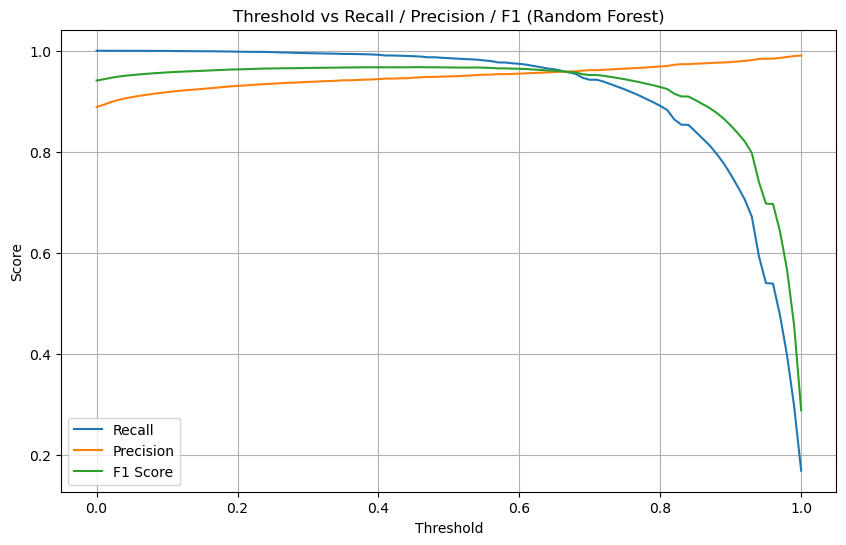

✅ Ngưỡng tối ưu theo F1: 0.46


In [532]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.plot(thresholds, recalls, label='Recall')
plt.plot(thresholds, precisions, label='Precision')
plt.plot(thresholds, f1s, label='F1 Score')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Threshold vs Recall / Precision / F1 (Random Forest)')
plt.legend()
plt.grid()
plt.show()

best_t = thresholds[np.argmax(f1s)] # Ngưỡng tốt nhất theo F1
print(f"✅ Ngưỡng tối ưu theo F1: {best_t:.2f}")

Evaluate the model at threshold = 0.7

In [533]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import pandas as pd

# Dự đoán lại theo ngưỡng mới
y_pred_thresh_rf = (y_scores_rf >= 0.7).astype(int)

# 📊 In classification report
print("📍 Classification Report tại threshold = 0.")
print(classification_report(y_test, y_pred_thresh_rf, target_names=["bad", "good"]))

# 📉 Confusion matrix
print("Confusion Matrix:")
print(pd.DataFrame(confusion_matrix(y_test, y_pred_thresh_rf),
                   index=["Actual: bad", "Actual: good"],
                   columns=["Predicted: bad", "Predicted: good"]))

# 🎯 AUC Score (vẫn dùng xác suất)
auc = roc_auc_score(y_test, y_scores_rf)
print(f"\n🎯 ROC AUC Score: {auc:.4f}")

📍 Classification Report tại threshold = 0.
              precision    recall  f1-score   support

         bad       0.62      0.69      0.65      2013
        good       0.96      0.95      0.95     16056

    accuracy                           0.92     18069
   macro avg       0.79      0.82      0.80     18069
weighted avg       0.92      0.92      0.92     18069

Confusion Matrix:
              Predicted: bad  Predicted: good
Actual: bad             1393              620
Actual: good             863            15193

🎯 ROC AUC Score: 0.9052


# XGboost

In [534]:
from xgboost import XGBClassifier
from xgboost import XGBRegressor
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import pandas as pd

1. Initialize and train the XGBoost model

In [535]:
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_model.fit(X_train_smote, y_train_smote)


/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [00:29:05] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

2. Prediction on test set

In [536]:
y_pred_xgb = xgb_model.predict(X_test_enc)
y_proba_xgb = xgb_model.predict_proba(X_test_enc)[:, 1]  # Xác suất cho class "good"

3. Print classification report

In [537]:
print("📊 XGBoost – Classification Report:")
print(classification_report(y_test, y_pred_xgb, target_names=["bad", "good"]))

📊 XGBoost – Classification Report:
              precision    recall  f1-score   support

         bad       0.88      0.54      0.67      2013
        good       0.95      0.99      0.97     16056

    accuracy                           0.94     18069
   macro avg       0.91      0.77      0.82     18069
weighted avg       0.94      0.94      0.93     18069



4. Confusion Matrix

In [538]:
print("\n📉 Confusion Matrix:")
print(pd.DataFrame(
    confusion_matrix(y_test, y_pred_xgb),
    index=["Actual: bad", "Actual: good"],
    columns=["Predicted: bad", "Predicted: good"]
))


📉 Confusion Matrix:
              Predicted: bad  Predicted: good
Actual: bad             1092              921
Actual: good             146            15910


5. ROC AUC Score

In [539]:
auc_score = roc_auc_score(y_test, y_proba_xgb)
print(f"\n🎯 ROC AUC Score: {auc_score:.4f}")


🎯 ROC AUC Score: 0.9074


# === Change custom threshold ===

In [540]:
threshold = 0.7  # có thể thử 0.3, 0.4, 0.5, ..., 0.9 để tìm giá trị phù hợp
y_pred_xgb_thresh = (y_proba_xgb >= threshold).astype(int)

# === Evaluate the model at the new threshold ===

In [541]:
print(f"\n📊 Classification Report tại threshold = {threshold}:")
print(classification_report(y_test, y_pred_xgb_thresh, target_names=["bad", "good"]))

print("\n📉 Confusion Matrix:")
print(pd.DataFrame(
    confusion_matrix(y_test, y_pred_xgb_thresh),
    index=["Actual: bad", "Actual: good"],
    columns=["Predicted: bad", "Predicted: good"]
))

print(f"🎯 ROC AUC Score (không đổi): {roc_auc_score(y_test, y_proba_xgb):.4f}")


📊 Classification Report tại threshold = 0.7:
              precision    recall  f1-score   support

         bad       0.74      0.63      0.68      2013
        good       0.95      0.97      0.96     16056

    accuracy                           0.93     18069
   macro avg       0.85      0.80      0.82     18069
weighted avg       0.93      0.93      0.93     18069


📉 Confusion Matrix:
              Predicted: bad  Predicted: good
Actual: bad             1270              743
Actual: good             454            15602
🎯 ROC AUC Score (không đổi): 0.9074


In [542]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [543]:
X = df_work.drop(columns=["target"])
y = df_work["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

for col in categorical_cols:
    X_train[col] = X_train[col].astype(str)
    X_test[col] = X_test[col].astype(str)

In [544]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ]
)

In [545]:
X_train_enc = preprocessor.fit_transform(X_train)
X_test_enc = preprocessor.transform(X_test)

from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_enc, y_train)

numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object', 'category']).columns.tolist()

In [546]:
from sklearn.pipeline import Pipeline
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])
cat_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', cat_transformer, categorical_features)
    ]
)

In [547]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
def cast_str(X):
    return X.astype(str)
cat_transformer = Pipeline(steps=[
    ('cast', FunctionTransformer(cast_str, validate=False)),
    ('onehot', OneHotEncoder(handle_unknown='ignore', dtype=int))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', cat_transformer, categorical_features)
    ],
    remainder='drop'
)

In [548]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
n_jobs = 1 
cv_folds = 3 

# === Draw Confusion Matrix at new threshold ===

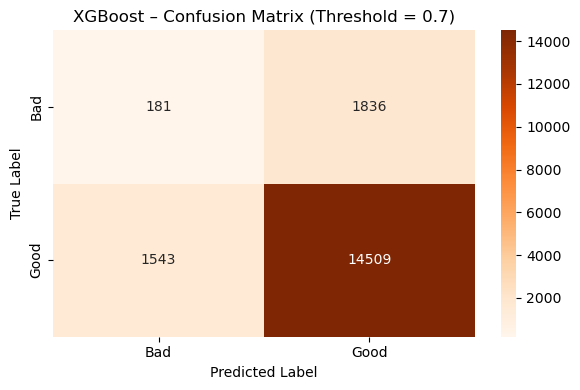

In [549]:
cm_xgb_thresh = confusion_matrix(y_test, y_pred_xgb_thresh)
labels = ["Bad", "Good"]

plt.figure(figsize=(6, 4))
sns.heatmap(cm_xgb_thresh, annot=True, fmt='d', cmap='Oranges', xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title(f"XGBoost – Confusion Matrix (Threshold = {threshold})")
plt.tight_layout()
plt.show()

In [550]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score

Get the predicted probability for the class "good"

In [551]:
y_scores = xgb_model.predict_proba(X_test_enc)[:, 1]

Loop through thresholds from 0.0 to 1.0

In [552]:
thresholds = np.arange(0.0, 1.01, 0.01)
precisions, recalls, f1s = [], [], []

for t in thresholds:
    y_pred_thresh = (y_scores >= t).astype(int)
    precisions.append(precision_score(y_test, y_pred_thresh))
    recalls.append(recall_score(y_test, y_pred_thresh))
    f1s.append(f1_score(y_test, y_pred_thresh))

/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Draw a chart

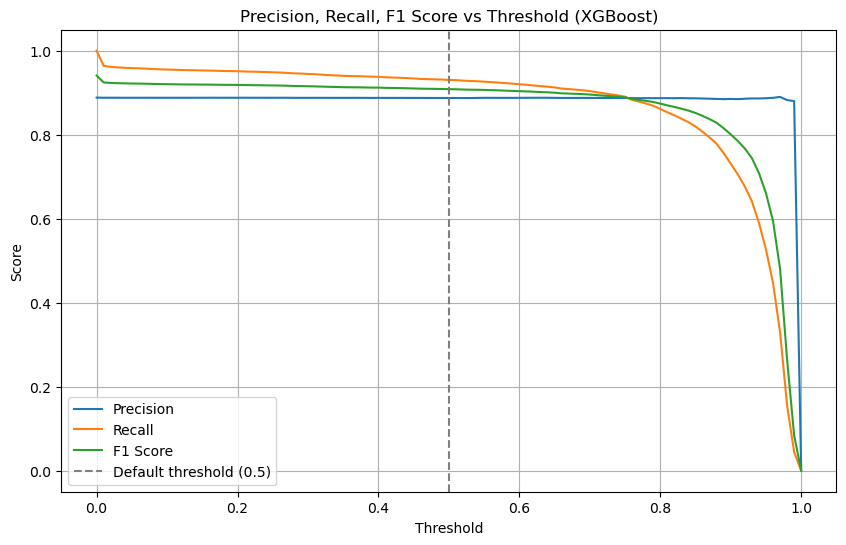

In [553]:
plt.figure(figsize=(10, 6))
plt.plot(thresholds, precisions, label='Precision')
plt.plot(thresholds, recalls, label='Recall')
plt.plot(thresholds, f1s, label='F1 Score')
plt.axvline(x=0.5, color='gray', linestyle='--', label='Default threshold (0.5)')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision, Recall, F1 Score vs Threshold (XGBoost)')
plt.legend()
plt.grid()
plt.show()

Print optimal threshold by F1 or you can choose by Recall

In [554]:
best_threshold = thresholds[np.argmax(f1s)]
print(f"✅ Ngưỡng tối ưu theo F1 Score: {best_threshold:.2f}")

y_pred_best = (y_scores >= best_threshold).astype(int)
print(classification_report(y_test, y_pred_best, target_names=["bad", "good"]))

✅ Ngưỡng tối ưu theo F1 Score: 0.00
              precision    recall  f1-score   support

         bad       0.00      0.00      0.00      2017
        good       0.89      1.00      0.94     16052

    accuracy                           0.89     18069
   macro avg       0.44      0.50      0.47     18069
weighted avg       0.79      0.89      0.84     18069



/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [555]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd

Make sure you have the variables:
y_test, y_pred_log, y_proba_log
y_pred_rf, y_proba_rf
y_pred_xgb, y_proba_xgb

Function to calculate evaluation indexes

In [556]:
def evaluate_model(name, y_true, y_pred, y_proba):
    return {
        'Model': name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred,pos_label=0),
        'F1 Score': f1_score(y_true, y_pred),
        'ROC AUC': roc_auc_score(y_true, y_proba)
    }

Combine the results of 3 models

In [557]:
results = [
    evaluate_model("Logistic Regression", y_test, y_pred_log, y_proba_log),
    evaluate_model("Random Forest", y_test, y_pred_rf_thresh, y_proba_rf),
    evaluate_model("XGBoost", y_test, y_pred_xgb, y_proba_xgb),
]

In [558]:
# Tạo bảng so sánh
df_results = pd.DataFrame(results)
df_results.set_index('Model', inplace=True)

# Hiển thị kết quả
print("🔍 So sánh hiệu suất 3 mô hình:")
display(df_results.round(4))


🔍 So sánh hiệu suất 3 mô hình:


,Accuracy,Precision,Recall,F1 Score,ROC AUC
Model,,,,,
Logistic Regression,0.7223,0.8856,0.1884,0.8347,0.4941
Random Forest,0.7893,0.8872,0.1155,0.8805,0.4855
XGBoost,0.8335,0.8875,0.0610,0.9085,0.4917


In [559]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

Calculate FPR and TPR for each model

In [560]:
fpr_log, tpr_log, _ = roc_curve(y_test, y_proba_log)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_proba_xgb)

Calculate AUC for each model

In [561]:
auc_log = auc(fpr_log, tpr_log)
auc_rf = auc(fpr_rf, tpr_rf)
auc_xgb = auc(fpr_xgb, tpr_xgb)

Draw a chart

/var/folders/2w/0ds979vs33z3m70t85hh_cp00000gn/T/ipykernel_70096/3303271663.py:15: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


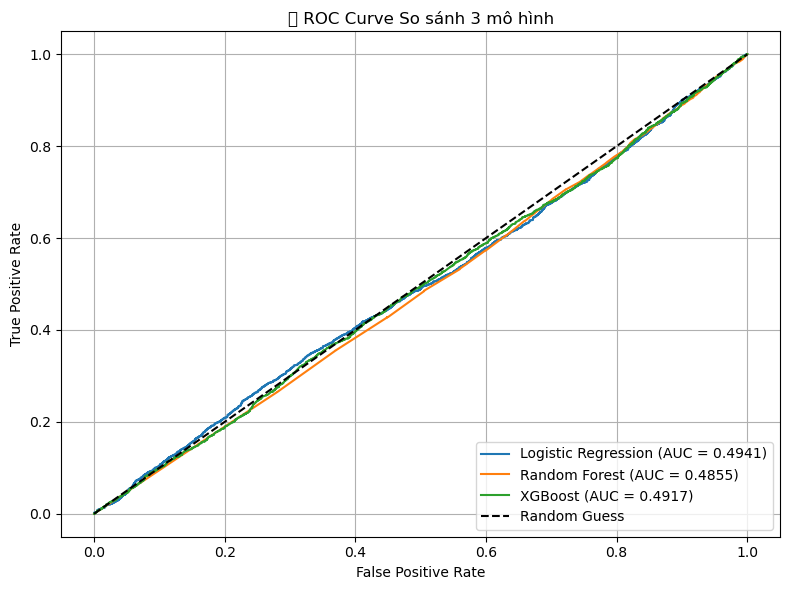

In [562]:
plt.figure(figsize=(8, 6))
plt.plot(fpr_log, tpr_log, label=f'Logistic Regression (AUC = {auc_log:.4f})')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.4f})')
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {auc_xgb:.4f})')

# Đường tham chiếu
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')

# Tùy chỉnh đồ họa
plt.title('🎯 ROC Curve So sánh 3 mô hình')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

In [563]:
'''
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
gbr_pipeline = Pipeline(steps=[('pre', preprocessor), ('model', GradientBoostingRegressor(random_state=42))])
gbr_params = {
    'model__n_estimators': [100, 200],
    'model__learning_rate': [0.05, 0.1]
}
gbr_grid = GridSearchCV(gbr_pipeline, gbr_params, cv=cv_folds,
                        scoring='neg_mean_squared_error', n_jobs=n_jobs)
print("Training Gradient Boosting...")
best_gbr = gbr_grid.fit(X_train, y_train).best_estimator_

y_pred_gbr = best_gbr.predict(X_test)

print("GBR Best Params:", gbr_grid.best_params_)
print("GBR MSE:", mean_squared_error(y_test, y_pred_gbr))
print("GBR R2:", r2_score(y_test, y_pred_gbr))
y_pred_gbr = best_gbr.predict(X_test)
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_gbr, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Target')
plt.ylabel('Predicted Target')
plt.title('GBR: Actual vs Predicted')
plt.grid(True)
plt.show()
mse_gbr = mean_squared_error(y_test, y_pred_gbr)
r2_gbr = r2_score(y_test, y_pred_gbr)
print(f"GBR Best Params: {gbr_grid.best_params_}")
print(f"GBR MSE: {mse_gbr:.4f}, R2: {r2_gbr:.4f}\n")

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
preprocessor_1 = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', Pipeline([
            ('cast', FunctionTransformer(cast_str, validate=False)),
            ('onehot', OneHotEncoder(handle_unknown='ignore', dtype=int))
        ]), categorical_features)
    ],
    remainder='drop'
)
model = Pipeline([
    ('pre', preprocessor_1),
    ('mlp', MLPRegressor(hidden_layer_sizes=(128, 64, 32), activation='relu', solver='adam',
                         alpha=0.001, learning_rate='adaptive', max_iter=500, random_state=42))
])

model.fit(X_train, y_train)

y_pred_mlp = model.predict(X_test)

mse_mlp = mean_squared_error(y_test, y_pred_mlp)
mae_mlp = mean_absolute_error(y_test, y_pred_mlp)
r2 = r2_score(y_test, y_pred_mlp)
print(f"Test MSE: {mse_mlp:.4f}")
print(f"Test MAE: {mae_mlp:.4f}")
print(f"Test R2: {r2:.4f}")

# Vẽ biểu đồ kết quả
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_mlp, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('MLP Regressor: Actual vs Predicted')
plt.grid(True)
plt.tight_layout()
plt.show()

# Define models and hyperparameters
residuals = y_test - y_pred_gbr
plt.figure(figsize=(6,4))
plt.hist(residuals, bins=30, edgecolor='k')
plt.xlabel('Residual')
plt.ylabel('Frequency')
plt.title('GBR Residuals Distribution')
plt.grid(True)
plt.show()
'''

'\nfrom sklearn.pipeline import Pipeline\nfrom sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor\ngbr_pipeline = Pipeline(steps=[(\'pre\', preprocessor), (\'model\', GradientBoostingRegressor(random_state=42))])\ngbr_params = {\n    \'model__n_estimators\': [100, 200],\n    \'model__learning_rate\': [0.05, 0.1]\n}\ngbr_grid = GridSearchCV(gbr_pipeline, gbr_params, cv=cv_folds,\n                        scoring=\'neg_mean_squared_error\', n_jobs=n_jobs)\nprint("Training Gradient Boosting...")\nbest_gbr = gbr_grid.fit(X_train, y_train).best_estimator_\n\ny_pred_gbr = best_gbr.predict(X_test)\n\nprint("GBR Best Params:", gbr_grid.best_params_)\nprint("GBR MSE:", mean_squared_error(y_test, y_pred_gbr))\nprint("GBR R2:", r2_score(y_test, y_pred_gbr))\ny_pred_gbr = best_gbr.predict(X_test)\nplt.figure(figsize=(6,6))\nplt.scatter(y_test, y_pred_gbr, alpha=0.6)\nplt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], \'r--\')\nplt.xlabel(\'Actual Target\')\np

# DATA VALIIDATION

In [564]:
import pandas as pd

Read data from Excel file

In [565]:
df_new = pd.read_excel('/Users/macbook/Desktop/TAXI_PRICE_EXTENSION/DATA/INSURANCE/FINAL EXAMINATION/Data-Validation.xlsx')  

df_new.head()

,MJACCTTYPCD,PHUONG THUC CHO VAY,LOAIKH,SEX,BASE_BAL,CURR_BAL,DUNO_QD,CURRENCYCD,OPEN_DATE,NGAYDENHAN,ID_TIME,DESC_TIME,MJACCTTYPDESC,ORGNBR,ORGNAME,PARENTORGNBR,PARENTORGNAME,LAISUAT,MUCDICHVAY
0,MTG,CV TL NH LAI DINH KY VND,1,ONG,200000000,200000000,200000000,VND,30/07/2020,30/07/2021,1,Vay ngan han,Vay Nong Nghiep,34,KLB - CN RACH GIA,34,KLB - CN RACH GIA,0.129,0111-Nong nghiep
1,MTG,CV TL NH LAI DINH KY VND,1,BA,330000000,330000000,330000000,VND,30/07/2020,30/07/2021,1,Vay ngan han,Vay Nong Nghiep,100,KLB - PGD CUKUIN,25,KLB - CN DAK LAK,0.111,0111-Nong nghiep
2,MTG,CV TL NH LAI DINH KY VND,1,ONG,30000000,30000000,30000000,VND,30/07/2020,30/07/2021,1,Vay ngan han,Vay Nong Nghiep,31,KLB - CN HAU GIANG,31,KLB - CN HAU GIANG,0.108,0131-Tmua-CB-BQ-TT luong thuc
3,MTG,CV TL NH LAI DINH KY VND,1,ONG,140000000,140000000,140000000,VND,43898,44263,1,Vay ngan han,Vay Nong Nghiep,32,KLB - PGD LONG MY,31,KLB - CN HAU GIANG,0.129,0111-Nong nghiep
4,CNS,"CV TL TH GOC, LAI D.KY VND",1,ONG,250000000,250000000,250000000,VND,43929,45755,2,Vay trung han,Vay Tieu dung,25,KLB - CN DAK LAK,25,KLB - CN DAK LAK,0.120,1830-CV Sua chua Nha de o


1. Normalize SEX column

In [566]:
sex_mapping = {
    'ONG': 'MR', 'MR': 'MR',
    'BA': 'MRS', 'MRS': 'MRS', 'MS': 'MRS'
}
df_new['SEX'] = df_new['SEX'].map(sex_mapping).fillna('UNKNOWN')

df_new['SEX'].unique()

array(['MR', 'MRS', 'UNKNOWN'], dtype=object)

Copy for processing

In [567]:
df_new["OPEN_DATE_clean"] = pd.NaT

For rows with numeric values ​​(serial date)

In [568]:
mask_numeric = df_new["OPEN_DATE"].apply(lambda x: str(x).replace('.', '').isnumeric())

The line is a valid date string.

In [569]:
mask_string = ~mask_numeric

In [570]:
# Áp dụng chuyển đổi với từng loại
# Fix: Apply the mask_numeric to df_new, not df
df_new.loc[mask_numeric, "OPEN_DATE_clean"] = pd.to_datetime(df_new.loc[mask_numeric, "OPEN_DATE"].astype(float),
                                                         origin="1899-12-30", unit="D", errors="coerce")

Apply the mask_string to df_new

In [571]:
df_new.loc[mask_string, "OPEN_DATE_clean"] = pd.to_datetime(df_new.loc[mask_string, "OPEN_DATE"],
                                                        format="%d/%m/%Y", errors="coerce")

Check the results

In [572]:
print(df_new[["OPEN_DATE", "OPEN_DATE_clean"]].head())

    OPEN_DATE OPEN_DATE_clean
0  30/07/2020      2020-07-30
1  30/07/2020      2020-07-30
2  30/07/2020      2020-07-30
3       43898      2020-03-08
4       43929      2020-04-08


Make clean column default to NaT

In [573]:
df_new["NGAYDENHAN_clean"] = pd.NaT

Mask number: check if it is Excel serial number

In [574]:
mask_numeric_ngay = df_new["NGAYDENHAN"].apply(lambda x: str(x).replace('.', '').isnumeric())

The rest is a series of days (reverse mask)

In [575]:
mask_string_ngay = ~mask_numeric_ngay

Convert numeric values ​​(Excel serial)

In [576]:
df_new.loc[mask_numeric_ngay, "NGAYDENHAN_clean"] = pd.to_datetime(
    df_new.loc[mask_numeric_ngay, "NGAYDENHAN"].astype(float),
    origin="1899-12-30", unit="D", errors="coerce"
)

Convert string value

In [577]:
df_new.loc[mask_string_ngay, "NGAYDENHAN_clean"] = pd.to_datetime(
    df_new.loc[mask_string_ngay, "NGAYDENHAN"],
    format="%d/%m/%Y", errors="coerce"
)

Check the results

In [578]:
print(df_new[["NGAYDENHAN", "NGAYDENHAN_clean"]].head())

   NGAYDENHAN NGAYDENHAN_clean
0  30/07/2021       2021-07-30
1  30/07/2021       2021-07-30
2  30/07/2021       2021-07-30
3       44263       2021-03-08
4       45755       2025-04-08


Create error checking mask in both columns

In [579]:
invalid_mask = df_new["OPEN_DATE_clean"].isna() | df_new["NGAYDENHAN_clean"].isna()

Filter lines with errors

In [580]:
invalid_rows = df_new[invalid_mask]

Filter lines with errors

In [581]:
num_invalid = invalid_rows.shape[0]
print(f"🛑 Số lượng dòng có lỗi trong OPEN_DATE_clean hoặc NGAYDENHAN_clean: {num_invalid}")

🛑 Số lượng dòng có lỗi trong OPEN_DATE_clean hoặc NGAYDENHAN_clean: 0


Show some original error examples

In [582]:
if num_invalid > 0:
    print("📋 Một số giá trị gốc bị lỗi khi chuyển datetime:")
    display(invalid_rows[["OPEN_DATE", "NGAYDENHAN"]].drop_duplicates().head(10))
else:
    print("✅ Không có lỗi nào trong OPEN_DATE_clean hoặc NGAYDENHAN_clean — tất cả đã chuyển đổi thành datetime thành công.")

df_new.head()

✅ Không có lỗi nào trong OPEN_DATE_clean hoặc NGAYDENHAN_clean — tất cả đã chuyển đổi thành datetime thành công.


,MJACCTTYPCD,PHUONG THUC CHO VAY,LOAIKH,SEX,BASE_BAL,CURR_BAL,DUNO_QD,CURRENCYCD,OPEN_DATE,NGAYDENHAN,ID_TIME,DESC_TIME,MJACCTTYPDESC,ORGNBR,ORGNAME,PARENTORGNBR,PARENTORGNAME,LAISUAT,MUCDICHVAY,OPEN_DATE_clean,NGAYDENHAN_clean
0,MTG,CV TL NH LAI DINH KY VND,1,MR,200000000,200000000,200000000,VND,30/07/2020,30/07/2021,1,Vay ngan han,Vay Nong Nghiep,34,KLB - CN RACH GIA,34,KLB - CN RACH GIA,0.129,0111-Nong nghiep,2020-07-30,2021-07-30
1,MTG,CV TL NH LAI DINH KY VND,1,MRS,330000000,330000000,330000000,VND,30/07/2020,30/07/2021,1,Vay ngan han,Vay Nong Nghiep,100,KLB - PGD CUKUIN,25,KLB - CN DAK LAK,0.111,0111-Nong nghiep,2020-07-30,2021-07-30
2,MTG,CV TL NH LAI DINH KY VND,1,MR,30000000,30000000,30000000,VND,30/07/2020,30/07/2021,1,Vay ngan han,Vay Nong Nghiep,31,KLB - CN HAU GIANG,31,KLB - CN HAU GIANG,0.108,0131-Tmua-CB-BQ-TT luong thuc,2020-07-30,2021-07-30
3,MTG,CV TL NH LAI DINH KY VND,1,MR,140000000,140000000,140000000,VND,43898,44263,1,Vay ngan han,Vay Nong Nghiep,32,KLB - PGD LONG MY,31,KLB - CN HAU GIANG,0.129,0111-Nong nghiep,2020-03-08,2021-03-08
4,CNS,"CV TL TH GOC, LAI D.KY VND",1,MR,250000000,250000000,250000000,VND,43929,45755,2,Vay trung han,Vay Tieu dung,25,KLB - CN DAK LAK,25,KLB - CN DAK LAK,0.120,1830-CV Sua chua Nha de o,2020-04-08,2025-04-08


Extract time component

In [583]:
df_new["OPEN_YEAR"] = df_new["OPEN_DATE_clean"].dt.year
df_new["OPEN_MONTH"] = df_new["OPEN_DATE_clean"].dt.month
df_new["OPEN_DAYOFWEEK"] = df_new["OPEN_DATE_clean"].dt.dayofweek  # 0 = Monday

Extract year, month, day of the week from the NgayDenhan_clean column

In [584]:
df_new["DUE_YEAR"] = df_new["NGAYDENHAN_clean"].dt.year
df_new["DUE_MONTH"] = df_new["NGAYDENHAN_clean"].dt.month
df_new["DUE_DAYOFWEEK"] = df_new["NGAYDENHAN_clean"].dt.dayofweek  # 0 = Monday, 6 = Sunday

df_new.head()

,MJACCTTYPCD,PHUONG THUC CHO VAY,LOAIKH,SEX,BASE_BAL,CURR_BAL,DUNO_QD,CURRENCYCD,OPEN_DATE,NGAYDENHAN,ID_TIME,DESC_TIME,MJACCTTYPDESC,ORGNBR,ORGNAME,PARENTORGNBR,PARENTORGNAME,LAISUAT,MUCDICHVAY,OPEN_DATE_clean,NGAYDENHAN_clean,OPEN_YEAR,OPEN_MONTH,OPEN_DAYOFWEEK,DUE_YEAR,DUE_MONTH,DUE_DAYOFWEEK
0,MTG,CV TL NH LAI DINH KY VND,1,MR,200000000,200000000,200000000,VND,30/07/2020,30/07/2021,1,Vay ngan han,Vay Nong Nghiep,34,KLB - CN RACH GIA,34,KLB - CN RACH GIA,0.129,0111-Nong nghiep,2020-07-30,2021-07-30,2020,7,3,2021,7,4
1,MTG,CV TL NH LAI DINH KY VND,1,MRS,330000000,330000000,330000000,VND,30/07/2020,30/07/2021,1,Vay ngan han,Vay Nong Nghiep,100,KLB - PGD CUKUIN,25,KLB - CN DAK LAK,0.111,0111-Nong nghiep,2020-07-30,2021-07-30,2020,7,3,2021,7,4
2,MTG,CV TL NH LAI DINH KY VND,1,MR,30000000,30000000,30000000,VND,30/07/2020,30/07/2021,1,Vay ngan han,Vay Nong Nghiep,31,KLB - CN HAU GIANG,31,KLB - CN HAU GIANG,0.108,0131-Tmua-CB-BQ-TT luong thuc,2020-07-30,2021-07-30,2020,7,3,2021,7,4
3,MTG,CV TL NH LAI DINH KY VND,1,MR,140000000,140000000,140000000,VND,43898,44263,1,Vay ngan han,Vay Nong Nghiep,32,KLB - PGD LONG MY,31,KLB - CN HAU GIANG,0.129,0111-Nong nghiep,2020-03-08,2021-03-08,2020,3,6,2021,3,0
4,CNS,"CV TL TH GOC, LAI D.KY VND",1,MR,250000000,250000000,250000000,VND,43929,45755,2,Vay trung han,Vay Tieu dung,25,KLB - CN DAK LAK,25,KLB - CN DAK LAK,0.120,1830-CV Sua chua Nha de o,2020-04-08,2025-04-08,2020,4,2,2025,4,1


Remove unused columns

In [585]:
selected_columns = [
    'PHUONG THUC CHO VAY', 'LOAIKH', 'SEX', 'CURRENCYCD', 'DESC_TIME',
    'MJACCTTYPDESC', 'ORGNAME', 'PARENTORGNAME', 'MUCDICHVAY',
    'BASE_BAL', 'CURR_BAL', 'DUNO_QD', 'LAISUAT',
    "OPEN_YEAR", "OPEN_MONTH", "OPEN_DAYOFWEEK",
    "DUE_YEAR", "DUE_MONTH", "DUE_DAYOFWEEK"
]

df_new_model = df_new[selected_columns].copy()

Only cast to string for categorical columns that exist in df_new_model

In [586]:
for col in categorical_cols:
    if col in df_new_model.columns:
        df_new_model[col] = df_new_model[col].astype(str)

In [587]:
df_new_model.head()

,PHUONG THUC CHO VAY,LOAIKH,SEX,CURRENCYCD,DESC_TIME,MJACCTTYPDESC,ORGNAME,PARENTORGNAME,MUCDICHVAY,BASE_BAL,CURR_BAL,DUNO_QD,LAISUAT,OPEN_YEAR,OPEN_MONTH,OPEN_DAYOFWEEK,DUE_YEAR,DUE_MONTH,DUE_DAYOFWEEK
0,CV TL NH LAI DINH KY VND,1,MR,VND,Vay ngan han,Vay Nong Nghiep,KLB - CN RACH GIA,KLB - CN RACH GIA,0111-Nong nghiep,200000000,200000000,200000000,0.129,2020,7,3,2021,7,4
1,CV TL NH LAI DINH KY VND,1,MRS,VND,Vay ngan han,Vay Nong Nghiep,KLB - PGD CUKUIN,KLB - CN DAK LAK,0111-Nong nghiep,330000000,330000000,330000000,0.111,2020,7,3,2021,7,4
2,CV TL NH LAI DINH KY VND,1,MR,VND,Vay ngan han,Vay Nong Nghiep,KLB - CN HAU GIANG,KLB - CN HAU GIANG,0131-Tmua-CB-BQ-TT luong thuc,30000000,30000000,30000000,0.108,2020,7,3,2021,7,4
3,CV TL NH LAI DINH KY VND,1,MR,VND,Vay ngan han,Vay Nong Nghiep,KLB - PGD LONG MY,KLB - CN HAU GIANG,0111-Nong nghiep,140000000,140000000,140000000,0.129,2020,3,6,2021,3,0
4,"CV TL TH GOC, LAI D.KY VND",1,MR,VND,Vay trung han,Vay Tieu dung,KLB - CN DAK LAK,KLB - CN DAK LAK,1830-CV Sua chua Nha de o,250000000,250000000,250000000,0.120,2020,4,2,2025,4,1


Encode new data

In [588]:
X_new_enc = preprocessor.transform(df_new_model)

df_new_model.head()

threshold = 0.7
df_new['proba_rf'] = rf_model.predict_proba(X_new_enc)[:, 1]
df_new['predicted_target_rf_thresh'] = (df_new['proba_rf'] >= threshold).astype(int)
df_new['predicted_label_rf_thresh'] = df_new['predicted_target_rf_thresh'].map({1: 'Good', 0: 'Bad'})

df_new.head()

print(df_new['predicted_label_rf_thresh'].value_counts())

NotFittedError: This ColumnTransformer instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.

Filter lines with proba_rf > 0.7

In [ ]:
filtered_df = df_new[df_new['proba_rf'] > 0.7]

KeyError: 'proba_rf'

Get unique values ​​in predicted_label_rf_thresh column

In [ ]:
unique_labels = filtered_df['predicted_label_rf_thresh'].unique()

print("Các giá trị unique của predicted_label_rf_thresh khi proba_rf > 0.7:")
print(unique_labels)

df_new.to_excel("du_lieu_du_doan_threshold_rf.xlsx", index=False)
print("✅ File đã được lưu thành công.")

NameError: name 'filtered_df' is not defined